# FNCE 449 Day 2 Assignment: Introduction to Algorithmic Trading

In this laboratory session, you are tasked with developing and assessing a basic algorithmic trading rule, focusing on the concept of **book skew**.

### Definition of Book Skew:
Book skew represents the imbalance between the resting bid depth ($v_b$) and the resting ask depth ($v_a$) at the top of the book. To normalize the values, we calculate their logarithmic difference as follows:

$$\text{skew} = \log v_b - \log v_a $$

### Intuition:
A higher bid depth usually indicates a higher demand to buy, potentially leading to increased prices. Based on this intuition, you will create a trading rule to buy when the skew is greater than a threshold $\theta$ and sell when the skew is less than $-\theta$.

### Assumptions:
- You will always trade one stock per transaction.
- There is a maximum position limit: You can hold a long position in at most 10 stocks and a short position in at most 10 stocks at any time.
- Use a skew threshold, $\theta=1.7$.
- Monitor the market every second. Ensure to resample the data to retain only the last observation recorded every second before executing the strategy.

### Tasks:
1. **Implementation:**
   Develop the described strategy for the Crude Oil Futures contract expiring in October 2023 (symbol: `CLX3`) on the CME.
   - Execute the strategy between 00:00 am on August 15, 2023, and 00:00 am on August 16, 2023. 
   - If the code takes too long, you can adjust the timespan of the execution with no penalty (as long as it exceeds three trading hours).
  
2. **Analysis and Visualization:**
   - Plot the following over time:
     - Profit
     - Position
     - Cumulative trading volume
   - Ensure to mark-to-market your position, valuing long positions at the bid and short positions at the ask.

### Evaluation Criteria:
- Correct and efficient implementation of the trading strategy.
- Accurate and clear plots representing profit, position, and cumulative trading volume over time.
- Proper handling and transformation of data, including resampling and mark-to-market valuation.


### Note:
- Pay attention to detail and ensure the accuracy of your implementation and plots.
- Clearly comment on your code to explain your implementation logic.

**Good luck!**


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
import databento as db

API_KEY = "db-RRkejP3pLR83aa7vkrtyTndLCNaey"
START = pd.Timestamp("2023-08-15 00:00:00", tz="America/New_York")
END = pd.Timestamp("2023-08-16 00:00:00", tz="America/New_York")
THETA = 1.7
MAX_POS = 10

plt.style.use("seaborn-v0_8-whitegrid")
print("Imports and parameters ready.")

Imports and parameters ready.


In [15]:
client = db.Historical(key=API_KEY)

book = client.timeseries.get_range(
    dataset="GLBX.MDP3",
    schema="mbp-1",
    symbols="CLX3",
    start=START,
    end=END,
)

book = book.to_df(tz="America/New_York")
print(f"Rows fetched: {len(book)}")
book.head()

Rows fetched: 370904


,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,flags,ts_in_delta,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00,symbol
ts_recv,,,,,,,,,,,,,,,,,,,
2023-08-15 00:00:19.576921403-04:00,2023-08-15 00:00:19.568786073-04:00,1,1,710431,C,B,0,81.45,1,128,16289,64524938,81.44,81.47,2,2,2,2,CLX3
2023-08-15 00:00:19.696499978-04:00,2023-08-15 00:00:19.696015693-04:00,1,1,710431,A,A,0,81.46,1,128,16859,64524978,81.44,81.46,2,1,2,1,CLX3
2023-08-15 00:00:19.698895464-04:00,2023-08-15 00:00:19.698114747-04:00,1,1,710431,A,A,0,81.46,1,128,23129,64525124,81.44,81.46,2,2,2,2,CLX3
2023-08-15 00:00:19.709147928-04:00,2023-08-15 00:00:19.708921633-04:00,1,1,710431,C,A,0,81.46,1,128,14406,64525292,81.44,81.46,2,1,2,1,CLX3
2023-08-15 00:00:19.727599350-04:00,2023-08-15 00:00:19.727438459-04:00,1,1,710431,C,A,0,81.46,1,128,16564,64525397,81.44,81.47,2,2,2,2,CLX3


In [16]:
# Step 3: Clean and organize the top-of-book data
book = book[["ts_event", "bid_px_00", "ask_px_00", "bid_sz_00", "ask_sz_00"]].copy()
book["ts_event"] = pd.to_datetime(book["ts_event"])
for col in ["bid_px_00", "ask_px_00", "bid_sz_00", "ask_sz_00"]:
    book[col] = pd.to_numeric(book[col], errors="coerce")
book = book.dropna().sort_values("ts_event").reset_index(drop=True)
book.head()


,ts_event,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00
0,2023-08-15 00:00:19.568786073-04:00,81.44,81.47,2,2
1,2023-08-15 00:00:19.696015693-04:00,81.44,81.46,2,1
2,2023-08-15 00:00:19.698114747-04:00,81.44,81.46,2,2
3,2023-08-15 00:00:19.708921633-04:00,81.44,81.46,2,1
4,2023-08-15 00:00:19.727438459-04:00,81.44,81.47,2,2


In [17]:
# Step 4: Resample to 1-second snapshots and compute skew
book_1s = book.set_index('ts_event').resample('1s').last().dropna().reset_index()
book_1s['vb'] = book_1s['bid_sz_00'].astype(float)
book_1s['va'] = book_1s['ask_sz_00'].astype(float)
book_1s['skew'] = np.log(book_1s['vb']) - np.log(book_1s['va'])
book_1s[['ts_event', 'bid_px_00', 'ask_px_00', 'vb', 'va', 'skew']].head()

,ts_event,bid_px_00,ask_px_00,vb,va,skew
0,2023-08-15 00:00:19-04:00,81.44,81.47,2.0,2.0,0.000000
1,2023-08-15 00:00:35-04:00,81.45,81.47,1.0,2.0,-0.693147
2,2023-08-15 00:01:08-04:00,81.46,81.48,2.0,3.0,-0.405465
3,2023-08-15 00:01:31-04:00,81.46,81.48,3.0,1.0,1.098612
4,2023-08-15 00:01:32-04:00,81.46,81.48,3.0,3.0,0.000000


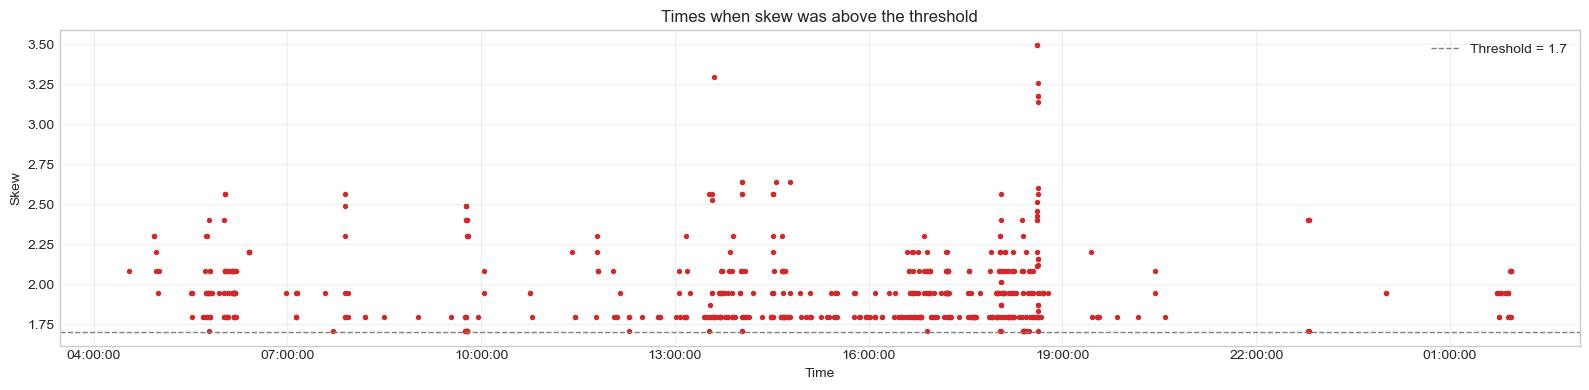

In [18]:
# Step 5: Implement the skew strategy
position = 0
cumulative_volume = 0
prev_mtm = 0.0
cumulative_pnl = 0.0
profit = []
position_history = []
volume_history = []
trade_log = []

for _, row in book_1s.iterrows():
    ts = row["ts_event"]
    bid = float(row["bid_px_00"])
    ask = float(row["ask_px_00"])
    skew = float(row["skew"])

    # Buy when the book is strongly bid-heavy, sell when it is strongly ask-heavy.
    if skew > THETA and position < MAX_POS:
        position += 1
        cumulative_volume += 1
        trade_log.append({"ts": ts, "side": "buy", "price": ask, "qty": 1})
    elif skew < -THETA and position > -MAX_POS:
        position -= 1
        cumulative_volume += 1
        trade_log.append({"ts": ts, "side": "sell", "price": bid, "qty": 1})

    # Mark-to-market current position value.
    mtm_value = position * bid if position > 0 else position * ask

    # Cumulative P&L equals the change in mark-to-market value from the previous step.
    cumulative_pnl += mtm_value - prev_mtm
    prev_mtm = mtm_value

    profit.append(cumulative_pnl)
    position_history.append(position)
    volume_history.append(cumulative_volume)

strategy = pd.DataFrame({
    "ts_event": book_1s["ts_event"],
    "position": position_history,
    "profit": profit,
    "cum_volume": volume_history,
    "skew": book_1s["skew"].values,
})

strategy.head()

skew_above = strategy.loc[strategy["skew"] > THETA, ["ts_event", "skew"]]

fig, ax = plt.subplots(figsize=(16, 4))
ax.scatter(skew_above["ts_event"], skew_above["skew"], s=8, color="tab:red")
ax.axhline(THETA, color="tab:gray", linestyle="--", linewidth=1, label=f"Threshold = {THETA}")
ax.set_title("Times when skew was above the threshold")
ax.set_ylabel("Skew")
ax.set_xlabel("Time")
ax.xaxis.set_major_formatter(DateFormatter("%H:%M:%S"))
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

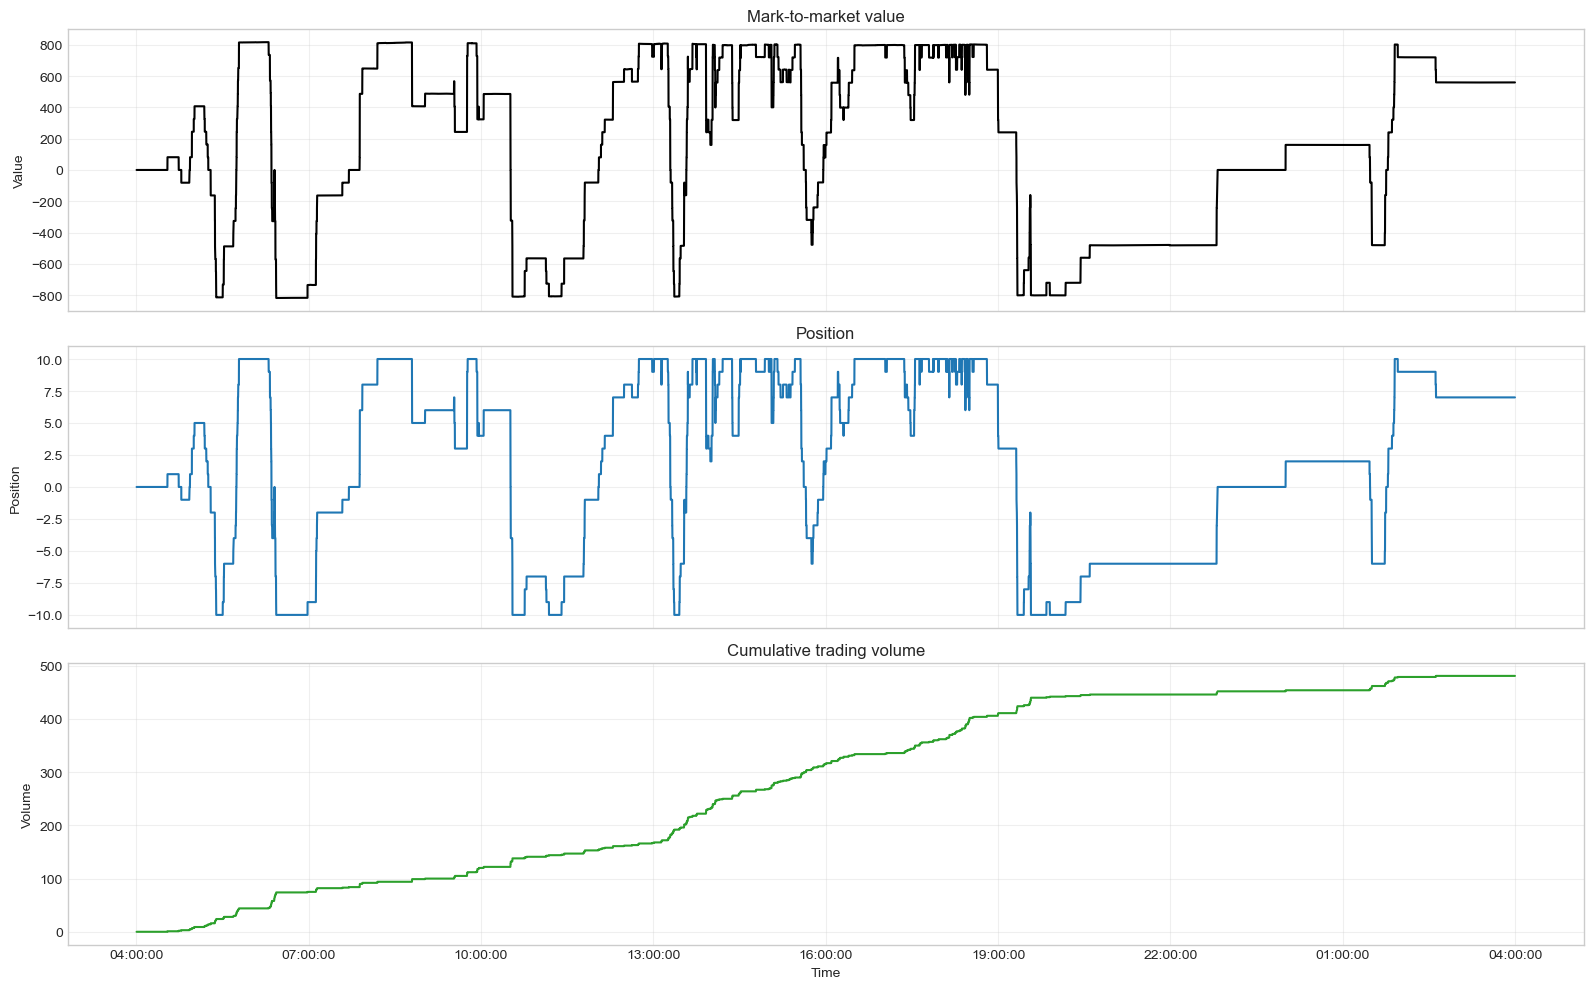

In [ ]:
# Step 6: Plot profit, position, and cumulative volume
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axes[0].plot(strategy["ts_event"], strategy["profit"], color="black", linewidth=1.5)
axes[0].set_title("Profit")
axes[0].set_ylabel("Profit")

axes[1].plot(strategy["ts_event"], strategy["position"], color="tab:blue", linewidth=1.5)
axes[1].set_title("Position")
axes[1].set_ylabel("Position")

axes[2].plot(strategy["ts_event"], strategy["cum_volume"], color="tab:green", linewidth=1.5)
axes[2].set_title("Cumulative trading volume")
axes[2].set_ylabel("Volume")
axes[2].set_xlabel("Time")

for ax in axes:
    ax.xaxis.set_major_formatter(DateFormatter("%H:%M:%S"))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()